In [1]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data = pd.read_csv('SouthofHeartFinal.csv', encoding='utf-8')
data.head()

,title,author,date,url,text
0,基督教發展史(七)─古典時代晚期8,黃文璋,2023/10/29 下午 04:27:29,https://stat.nuk.edu.tw/SouthShow.asp?myid=2083,被判為“異端”者，只是對教義的解釋與主流教派不同，終究並非犯了什麼十惡不赦的罪過，因而仍可能...
1,基督教發展史(七)─古典時代晚期7,黃文璋,2023/10/22 上午 11:11:37,https://stat.nuk.edu.tw/SouthShow.asp?myid=2082,402年，西哥德人在國王阿拉里克(Alaric，亦稱阿拉里克一世(Alaric I)，約37...
2,基督教發展史(七)─古典時代晚期6,黃文璋,2023/10/16 上午 10:38:15,https://stat.nuk.edu.tw/SouthShow.asp?myid=2081,大約在380年，西班牙和亞奎丹(Aquitaine，又譯阿基坦，法國西南部之一大區)的主教會...
3,基督教發展史(七)─古典時代晚期5,黃文璋,2023/10/8 上午 11:18:57,https://stat.nuk.edu.tw/SouthShow.asp?myid=2080,381年的“第一次君士坦丁堡公會議”，通過一影響深遠的決議，即禁止所有異教與異端教派。那時的...
4,基督教發展史(七)─古典時代晚期4,黃文璋,2023/10/1 上午 09:51:13,https://stat.nuk.edu.tw/SouthShow.asp?myid=2079,狄奧多西一世在基督教家庭中成長。登基後的隔年，380年2月27日，他與西部皇帝格拉提安，共同...


In [3]:
data['date'] = data['date'].str.replace('上午', 'AM').str.replace('下午', 'PM')
data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d %p %I:%M:%S')
data['date'] = data['date'].dt.date
data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data = data.drop(columns=['url', 'date'])

In [4]:
data.head()

,title,author,text,year,month,day
0,基督教發展史(七)─古典時代晚期8,黃文璋,被判為“異端”者，只是對教義的解釋與主流教派不同，終究並非犯了什麼十惡不赦的罪過，因而仍可能...,2023,10,29
1,基督教發展史(七)─古典時代晚期7,黃文璋,402年，西哥德人在國王阿拉里克(Alaric，亦稱阿拉里克一世(Alaric I)，約37...,2023,10,22
2,基督教發展史(七)─古典時代晚期6,黃文璋,大約在380年，西班牙和亞奎丹(Aquitaine，又譯阿基坦，法國西南部之一大區)的主教會...,2023,10,16
3,基督教發展史(七)─古典時代晚期5,黃文璋,381年的“第一次君士坦丁堡公會議”，通過一影響深遠的決議，即禁止所有異教與異端教派。那時的...,2023,10,8
4,基督教發展史(七)─古典時代晚期4,黃文璋,狄奧多西一世在基督教家庭中成長。登基後的隔年，380年2月27日，他與西部皇帝格拉提安，共同...,2023,10,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1097 non-null   object
 1   author  1097 non-null   object
 2   text    1095 non-null   object
 3   year    1097 non-null   int32 
 4   month   1097 non-null   int32 
 5   day     1097 non-null   int32 
dtypes: int32(3), object(3)
memory usage: 38.7+ KB


In [6]:
data["text"] = data["text"].fillna("") 

---

### 👀黃老師於2014年8月1日退休

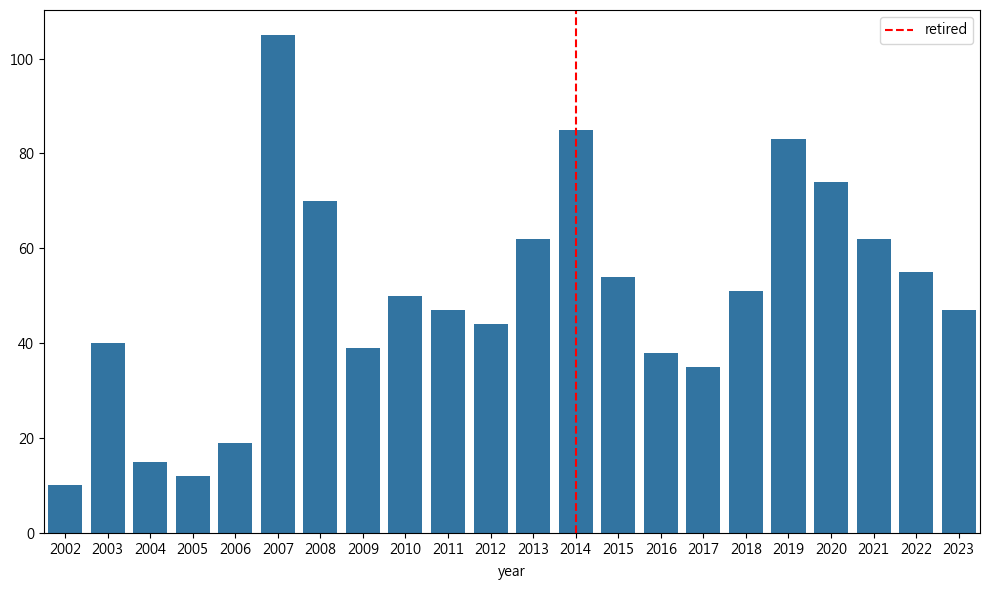

In [7]:
year_counts = data['year'].value_counts().sort_index()
years = list(year_counts.index)

plt.figure(figsize=(10, 6))
sns.barplot(x=data['year'].value_counts().index, y=data['year'].value_counts().values)

if 2014 in years:
    pos = years.index(2014)
    plt.axvline(x=pos, color='red', linestyle='--', label='retired')

plt.legend()    
plt.tight_layout()
plt.show()

---

### 👀依月份分組, 查看各月份的文章數

C:\Users\No\AppData\Local\Temp\ipykernel_18940\1073746100.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


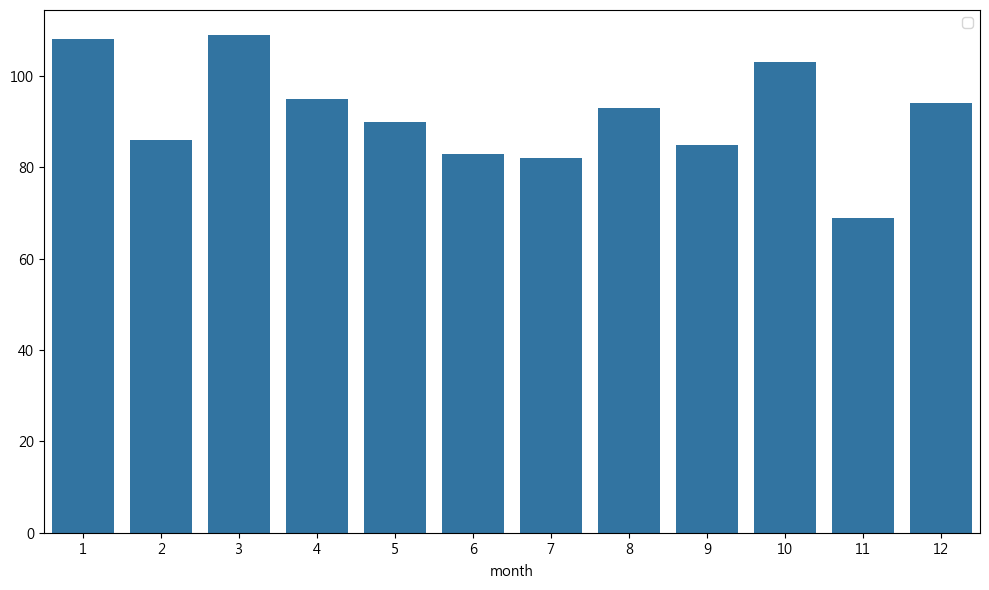

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x=data['month'].value_counts().index, y=data['month'].value_counts().values)
plt.legend()    
plt.tight_layout()
plt.show()

#### 黃老師寫文章的習慣沒有隨著季節變化而有區別
---

### 👀黃老師用真名、筆名的次數統計

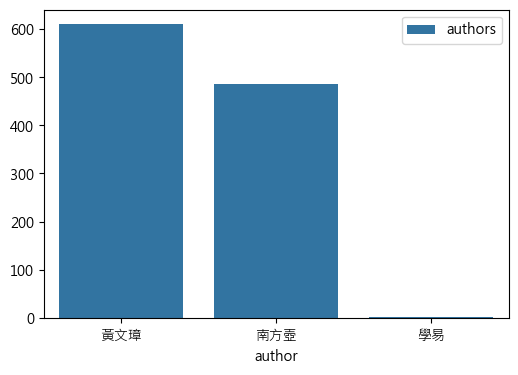

In [9]:
plt.figure(figsize=(6, 4))
sns.barplot(x=data['author'].value_counts().index, y=data['author'].value_counts().values, label='authors')
plt.show()

In [10]:
data.loc[data['author'] == '學易']

,title,author,text,year,month,day
1068,容易受傷的男人,學易,經過幾天的陰陰雨雨，天氣又好起來。昨晚高中同學莉莉約我今天中午見面。電話中她顯得心情很愉快的...,2003,4,14


#### 黃老師用真名的次數最多, 用筆名'學易'的次數僅一次

---

In [11]:
name_group = data.groupby('year')['author'].value_counts().reset_index(name='counts')
name_group.head()

,year,author,counts
0,2002,南方壺,7
1,2002,黃文璋,3
2,2003,南方壺,33
3,2003,黃文璋,6
4,2003,學易,1


### 👀黃老師使用筆名和真名的次數

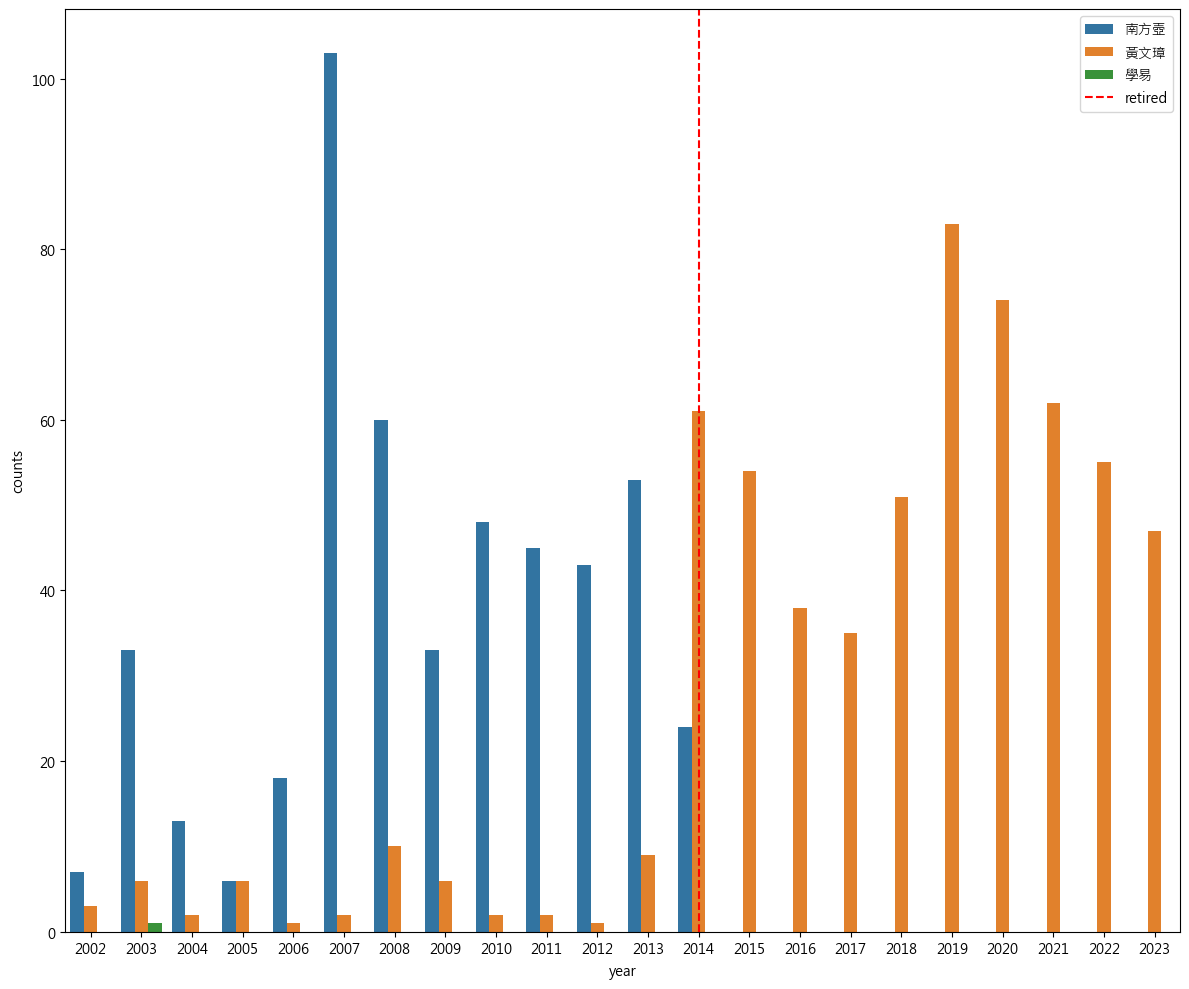

In [12]:
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # 微軟正黑體（Windows）
plt.figure(figsize=(12, 10))
sns.barplot(name_group, x='year', y='counts', hue='author')
if 2014 in years:
    pos = years.index(2014)
    plt.axvline(x=pos, color='red', linestyle='--', label='retired')
plt.legend()
plt.tight_layout()
plt.show()

#### 於退休前大部分時用筆名, 退休後都是用真名

---

In [13]:
data.loc[(data['author'] == '南方壺') & (
    (data['year'] < 2014) | ((data['year'] == 2014) & (data['month'] < 8))
    )].reset_index(drop=True)

,title,author,text,year,month,day
0,關上酒店我就走,南方壺,民國99年11月，中山大學慶祝設校三十週年，應用數學系找我回去演講。我以“三十年絃歌”為題，...,2014,7,31
1,有言論自由嗎？,南方壺,近來我常覺校務沒什麼好談，政治也不必多談，因就是那樣子了，由於自顧無長策，只好萬事不關心。多...,2014,7,21
2,真在乎論文嗎？,南方壺,在巴西舉行的2014年世界盃足球賽剛結束，如眾所預期，由德國獲得冠軍。在超過一個月的比賽期間...,2014,7,15
3,平生風義兼師友,南方壺,我國當代著名統計學家，曾任中央研究院統計科學研究所所長的魏慶榮(1949-2004)教授過世...,2014,6,30
4,知識分子,南方壺,最近俞成送了我一本余英時(1930-)著的“歷史與思想”。大家知道，余英時是我國旅美著名學者...,2014,6,25
...,...,...,...,...,...,...
480,真愛一世情,南方壺,來自澳洲的凱特布蘭琪，1998年以伊莉沙白一片和葛妮絲派特洛主演的莎翁情史角逐奧斯卡影后落敗...,2002,12,20
481,蘇菲亞的選擇,南方壺,梅莉史翠普這位被譽為八十年代最佳女演員，我剛到美國留學時，她剛出道未久，有一系列的好作品。如...,2002,12,16
482,純真年代,南方壺,一個住紐約掌管一家大公司的企業家，在聖誕夜夢見與十三年前的女友，共組家庭有兩個可愛的小孩，過...,2002,12,11
483,找回戰場的將軍,南方壺,一位受人尊敬的美國上將，因違反上級命令，指揮錯誤，致使部屬犧牲，而順服地入了軍事監獄。獄中有...,2002,12,9


In [14]:
data.loc[(data['author'] == '黃文璋') & (data['year'] <= 2014)]

,title,author,text,year,month,day
499,41 二項分佈到常態分佈,黃文璋,持續投擲一出現正面機率為p之銅板，各次投擲假設為相互獨立，則n次後，所得之正面數Sn，有二項...,2014,12,24
500,40 誰該說服誰？,黃文璋,民國103年12月21日，各大報均有關於台北市“忠孝西路公車道去留”的新聞。底下報導乃取自中...,2014,12,22
501,統計學入門─序,黃文璋,民國103年8月起退休，成為無業遊民。每天待在家中，加入宅男一族。該找些事來做，但能做些什麼...,2014,12,20
502,39 統計與證明,黃文璋,在二月河(1997)一書頁54-57，講了一與統計有關的故事。清朝施琅(1621-1696)...,2014,12,16
503,38 假設檢定,黃文璋,在“論語”“先進篇”：子路、曾皙、冉有、公西華侍坐。子曰“以吾一日長乎爾，毋吾以也。居則曰‘...,2014,12,14
...,...,...,...,...,...,...
1073,無遠弗屆,黃文璋,"民國66年暑假, 我一位大學同班好友即將出國深造, 我買了一個手表送他。我們初中同班, ...",2003,3,7
1086,我拿青春賭明天,黃文璋,現在中、小學課程中，加進不少機率以及統計的題材。此因我們處於一隨機的世界，常需處理不確定的事...,2003,1,4
1090,密碼,黃文璋,我們處在一個密碼的時代。 年輕人以手機傳簡訊， 520表我愛你，5120184表我要愛你...,2002,12,16
1093,十年的回顧,黃文璋,南區統計研討會是民國八十一年首度舉辦的。那年暑假中央研究院統計科學研究所為慶祝成立十週年，邀...,2002,12,10


In [15]:
South = data.loc[data['author'] == '南方壺'].reset_index(drop=True)
South.head()

,title,author,text,year,month,day
0,女兒跨出了一步,南方壺,在美國普渡大學(Purdue University)統計系就讀的女兒，已於當地時間12月2日...,2014,12,3
1,關上酒店我就走,南方壺,民國99年11月，中山大學慶祝設校三十週年，應用數學系找我回去演講。我以“三十年絃歌”為題，...,2014,7,31
2,有言論自由嗎？,南方壺,近來我常覺校務沒什麼好談，政治也不必多談，因就是那樣子了，由於自顧無長策，只好萬事不關心。多...,2014,7,21
3,真在乎論文嗎？,南方壺,在巴西舉行的2014年世界盃足球賽剛結束，如眾所預期，由德國獲得冠軍。在超過一個月的比賽期間...,2014,7,15
4,平生風義兼師友,南方壺,我國當代著名統計學家，曾任中央研究院統計科學研究所所長的魏慶榮(1949-2004)教授過世...,2014,6,30


#### 這邊可以注意到在退休後(2014.8.1後)的12月3日用了最後一次的筆名'南方壺'

[文章網址](https://stat.nuk.edu.tw/SouthShow.asp?myid=1526)

In [16]:
data.loc[(data['year'] == 2014) & (data['month'] == 12) & (data['day'] == 3)]

,title,author,text,year,month,day
507,女兒跨出了一步,南方壺,在美國普渡大學(Purdue University)統計系就讀的女兒，已於當地時間12月2日...,2014,12,3


---

In [17]:
Realname = data.loc[data['author'] == '黃文璋'].reset_index(drop=True)
Realname.head()

,title,author,text,year,month,day
0,基督教發展史(七)─古典時代晚期8,黃文璋,被判為“異端”者，只是對教義的解釋與主流教派不同，終究並非犯了什麼十惡不赦的罪過，因而仍可能...,2023,10,29
1,基督教發展史(七)─古典時代晚期7,黃文璋,402年，西哥德人在國王阿拉里克(Alaric，亦稱阿拉里克一世(Alaric I)，約37...,2023,10,22
2,基督教發展史(七)─古典時代晚期6,黃文璋,大約在380年，西班牙和亞奎丹(Aquitaine，又譯阿基坦，法國西南部之一大區)的主教會...,2023,10,16
3,基督教發展史(七)─古典時代晚期5,黃文璋,381年的“第一次君士坦丁堡公會議”，通過一影響深遠的決議，即禁止所有異教與異端教派。那時的...,2023,10,8
4,基督教發展史(七)─古典時代晚期4,黃文璋,狄奧多西一世在基督教家庭中成長。登基後的隔年，380年2月27日，他與西部皇帝格拉提安，共同...,2023,10,1


---

### 👀黃老師出生於民國43年5月27日出生於高雄旗津


In [18]:
data.loc[(data['month'] == 5)&(data['day'] == 27)]

,title,author,text,year,month,day
860,勇闖天涯路─3,南方壺,史丹佛大學位於美國加州，在舊金山的東南約60公里，差不多 1小時車程。距高科技公司雲集的的...,2008,5,27


#### 僅有一篇文章, 且文章標題、內容與黃老師的生日無相關

---

In [19]:
pp = (data.groupby('month')['day'].value_counts().reset_index(name='counts'))
max_ = pp.loc[pp['counts'].idxmax()]
print(max_)

month      3
day       20
counts    10
Name: 59, dtype: int64


### 👀黃老師寫文章數量最多的日期

In [20]:
data.loc[(data['month'] == 3)&(data['day'] == 20)]

,title,author,text,year,month,day
90,真相是時間的女兒(二),黃文璋,今日天主教(Catholicism)教會擁有崇高的社會地位，但在中世紀(Middle Age...,2022,3,20
147,英式擇偶(二百二十五),黃文璋,225咆哮山莊(九十七)“我急著要走，不想跟這個無賴繼續糾纏，凱薩琳卻一點都不急。她說‘再待...,2021,3,20
438,跟著聖經神遊八方(二十六),黃文璋,2亞歷山大亞歷山大大帝，是在他那位知名的希臘前輩希羅多德去世(約西元前425年)後，約過了7...,2016,3,20
479,數據素養(四)─表格2,黃文璋,表9 104學年度學科能力測驗各科級分人數百分比累計表(續)表9-3數學級分人數百分比累計人...,2015,3,20
480,數據素養(四)─表格1,黃文璋,表8 104學年度學科能力測驗原始分數與級分對照表科目國文英文數學社會自然級距5.906.3...,2015,3,20
481,數據素養(四),黃文璋,4關於學測級分的探討(一)目前高中生想進大學，學測是一很關鍵的考試。這是從民國83年開始舉行...,2015,3,20
565,之後再無大師(六),黃文璋,幾年前曾看過大陸作家岳南(1962-)所著的“之後再無大師”一書，寫民國以來，一些我們耳熟能...,2014,3,20
629,比下有餘,南方壺,有一女孩，在爸媽陪同下，跟一男孩家裡談婚事。本以為所謂“談”，不過是形式而已，也就是雙方見個...,2013,3,20
817,得意的笑,南方壺,3月19日台北地方法院審理陳水扁家的弊案，吳淑珍和陳鎮慧當庭對質。為扁家管帳二十餘年的陳鎮慧...,2009,3,20
959,孩子的爸,南方壺,"現在年輕人可能不太知道林語堂了,我大學時搜尋他從三十年代開始所寫的各種書籍,不論雜文或小說,...",2007,3,20


#### 但這個日期不具有任何代表性, 且與文章標題、內容無相關

---

In [21]:
data[data['title'].str.contains('南區')]

,title,author,text,year,month,day
17,南區統計三十二年,黃文璋,東華大學成立於民國83年，第1年便有應用數學研究所碩士班。因緣際會，東華應數籌備時期，我曾參...,2023,7,3
112,南區統計三十年,黃文璋,第一屆南區(原名高雄區，自第三屆起改名南區並沿用至今)統計研討會，乃於1992年6月25、2...,2021,10,23
191,南區統計二十九年,黃文璋,中正大學成立於1989年，第一年便設立應用數學研究所，去年2019年成立30周年。今年是第二...,2020,8,21
281,第二十八屆南區統計研討會開幕致詞,黃文璋,第1屆南區統計研討會，於民國81年，在中山大學應用數學系舉行。今年民國108年，第28屆南區...,2019,6,24
282,南區統計二十八年,黃文璋,今年將舉行第二十八屆南區統計研討會(南區)，是南區第一次由國立中興大學主辦，也是第一次到臺中...,2019,6,22
352,南區統計二十七年,黃文璋,第二十七屆南區統計研討會，於2018年6月29日至30日，在國立成功大學統計學系舉行。這是成...,2018,7,1
389,第二十六屆南區統計研討會開幕致詞,黃文璋,很高興來參加南區統計研討會。前陣子看到CNN的一則報導，對一個樂團能在一個月內，在同一個城市...,2017,6,25
390,南區統計二十六年,黃文璋,一年一度的南區統計研討會(簡稱南區)，今年6月23、24日，在國立臺北大學舉行。中華機率統計...,2017,6,25
428,南區統計二十五年,黃文璋,民國81年，中山大學成立第12年，仍算是所新大學。當時國內不但大學不多，統計相關的研究所亦屈...,2016,6,27
616,南區統計二十二年,黃文璋,在金庸(1924-)小說裡，華山論劍究竟有幾次？許多年前，在初到中山大學的第二年，我曾問過一...,2013,6,4


# BERTopic

In [22]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.preprocessing import normalize
import jieba
from pathlib import Path
import nltk
import re
from nltk.corpus import stopwords
from umap import UMAP
from sentence_transformers import SentenceTransformer
import string
import unicodedata

In [23]:
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance    

In [24]:
def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))  # 刪標點
    text = re.sub(r'\[.*?\]', '', text)                               # 刪 [] 內內容
    text = re.sub(r'https?://\S+|www\.\S+', '', text)                 # 刪網址
    text = re.sub(r'<.*?>+', '', text)                                # 刪 HTML tag
    text = re.sub(r'\n', ' ', text)                                   # 換行→空白
    text = re.sub(r'\w*\d\w*', ' ', text)                             # 含數字詞
    text = re.sub(r'\d+', ' ', text)                                  # 數字
    # text = ''.join(ch for ch in text if unicodedata.category(ch)[0] != 'P')
    text = re.sub(r'\s+', ' ', text).strip()                          # 連續空白
    return text
data["cleaned_text"] = data["text"].apply(clean_text)
data.head()

,title,author,text,year,month,day,cleaned_text
0,基督教發展史(七)─古典時代晚期8,黃文璋,被判為“異端”者，只是對教義的解釋與主流教派不同，終究並非犯了什麼十惡不赦的罪過，因而仍可能...,2023,10,29,被判為“異端”者，只是對教義的解釋與主流教派不同，終究並非犯了什麼十惡不赦的罪過，因而仍可能...
1,基督教發展史(七)─古典時代晚期7,黃文璋,402年，西哥德人在國王阿拉里克(Alaric，亦稱阿拉里克一世(Alaric I)，約37...,2023,10,22,，西哥德人在國王阿拉里克alaric，亦稱阿拉里克一世alaric i， ， ，入侵義大利。...
2,基督教發展史(七)─古典時代晚期6,黃文璋,大約在380年，西班牙和亞奎丹(Aquitaine，又譯阿基坦，法國西南部之一大區)的主教會...,2023,10,16,，西班牙和亞奎丹aquitaine，又譯阿基坦，法國西南部之一大區的主教會議，在西班牙東北部...
3,基督教發展史(七)─古典時代晚期5,黃文璋,381年的“第一次君士坦丁堡公會議”，通過一影響深遠的決議，即禁止所有異教與異端教派。那時的...,2023,10,8,“第一次君士坦丁堡公會議”，通過一影響深遠的決議，即禁止所有異教與異端教派。那時的異教，大致...
4,基督教發展史(七)─古典時代晚期4,黃文璋,狄奧多西一世在基督教家庭中成長。登基後的隔年，380年2月27日，他與西部皇帝格拉提安，共同...,2023,10,1,狄奧多西一世在基督教家庭中成長。登基後的隔年， ，他與西部皇帝格拉提安，共同頒布“帖撒羅尼迦...


In [25]:
docs = data["cleaned_text"].tolist()

In [26]:
kernelPCA = KernelPCA(n_components=5, kernel='cosine', gamma=1, random_state=42, n_jobs=-1)
kmeans = KMeans(n_clusters=10, n_init=5, max_iter=150, random_state=42)
# hdbscan = HDBSCAN(min_cluster_size=7, n_jobs=-1, min_samples=10)
# ump = UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42, n_jobs=-1, min_dist=0.0)

### Fine tune 會更好

In [27]:
sentence_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
embeddings = sentence_model.encode(docs, show_progress_bar=True)

umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=10, metric='euclidean', cluster_selection_method='eom')

representation_model = MaximalMarginalRelevance(diversity=0.3)
vectorizer_model = CountVectorizer(stop_words='english')

topic_model = BERTopic(embedding_model=sentence_model,
                        vectorizer_model=vectorizer_model,
                        calculate_probabilities=True,
                        umap_model=kernelPCA,
                        hdbscan_model=kmeans,
                        representation_model=representation_model,
                        verbose=True)

Topics, Probs = topic_model.fit_transform(docs, embeddings)

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

2025-06-27 18:16:51,097 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-27 18:16:51,233 - BERTopic - Dimensionality - Completed ✓
2025-06-27 18:16:51,235 - BERTopic - Cluster - Start clustering the reduced embeddings
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^

In [28]:
# topic_model = BERTopic(calculate_probabilities=True, 
#                        verbose=True,
#                        language="multilingual",
#                        vectorizer_model=cv,
#                        umap_model=UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42, n_jobs=-1, min_dist=0.01),
#                        hdbscan_model=HDBSCAN(min_cluster_size=10, n_jobs=-1)
#                        )
# 0.4905

# topic_model = BERTopic(calculate_probabilities=True, 
#                        verbose=True,
#                        language="multilingual",
#                        vectorizer_model=cv,
#                        umap_model=KernelPCA(n_components=5, kernel='cosine', gamma=0.5, random_state=42, n_jobs=-1),
#                        hdbscan_model=KMeans(n_clusters=10, n_init=5, max_iter=150, random_state=42),
#                        )
# 0.5936

In [29]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,152,0_她說_娜莉_伊莉莎白說_夫人,"[她說, 娜莉, 伊莉莎白說, 夫人, 達西說, 我說, 伊莉莎白, 希斯克里夫說, 林頓說...",[“我一路心情沉重，跟著凱薩琳到了咆哮山莊。我們從廚房那裡進去，想先確定希斯克里夫是否真的不...
1,1,143,1_傲慢與偏見_勸導_理性與感性_哈利波特,"[傲慢與偏見, 勸導, 理性與感性, 哈利波特, woman, 艾瑪, love, 第一印象...",[：xx餐廳請來英國米其林二星廚師xxx…。xx大酒店請來獲得米其林三星殊榮的大廚xxx…。...
2,2,133,2_px_傳統_的文章_另一方面,"[px, 傳統, 的文章, 另一方面, correlation, xn, statistic...",[有沒有關係？人們常會提到“關係”一詞。生活裡充滿著各種關係，如親子關係、婆媳關係、勞資關係...
3,3,116,3_例如_大考中心_數學傳播季刊_大學,"[例如, 大考中心, 數學傳播季刊, 大學, 補充說明, 大學招聯會, 研究型, 教學型, ...",[“治大國若烹小鮮”，出自老子“道德經”。意思是說，治理大國與煎小魚一般，不能常去翻動，否則...
4,4,116,4_我這樣想_齊瓦哥醫生_學然後知不足_university,"[我這樣想, 齊瓦哥醫生, 學然後知不足, university, 另一方面, 假設性的問題...",[在美國普渡大學purdue university統計系就讀的女兒， ，順利通過口試。這幾天...
5,5,114,5_聖經_福音書_創世紀_路加福音,"[聖經, 福音書, 創世紀, 路加福音, 使徒行傳, 撒母耳記上, 出埃及記, 日內瓦聖經,...",[“新約” ， ： “福音書”、 “使徒行傳”、 “保羅書信”、 “大公書信”catholi...
6,6,108,6_一般而言_或x_平均壽命_不可能,"[一般而言, 或x, 平均壽命, 不可能, distribution, hypothesis...",[，甚至還有人以為，數學所做的事，就是證明。一命題若經證明為真，便毫無例外地成立。例如，直角...
7,7,107,7_史記_文學文摘_橄欖樹_舊約,"[史記, 文學文摘, 橄欖樹, 舊約, 數學傳播, 殷墟, 列王記上, 懷瑾, 之後再無大師...",[“史記”，記載自傳說中的黃帝以來， ， ， ，那幾千年間中國的歷史。分成“本紀”、“表”、...
8,8,76,8_duke_earl_beaufort_henry,"[duke, earl, beaufort, henry, battle, richard,...",[金雀花王朝的臣民，常會留意王位的繼承問題，因他們的國王屢屢活躍於國內外戰場，而古來征戰幾人...
9,9,32,9____,"[, , , , , , , , , , , , , , , , , , , , , , ,...","[, , ]"


In [30]:
topic_model.visualize_topics()

In [31]:
topic_model.visualize_documents(docs, hide_annotations=True, custom_labels=True, topics=list(range(30)))

In [32]:
topic_model.visualize_barchart(top_n_topics=8, n_words=8)

# ✅ Topic Coherence / Diversity

In [33]:
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

In [35]:
# documents = pd.DataFrame({"Document": docs,
#                           "ID": range(len(docs)),
#                           "Topic": topics})
# # 把每個主題的文章湊成一行
# documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})

# cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

# vectorizer = topic_model.vectorizer_model
# analyzer = vectorizer.build_analyzer()

# tokens = [analyzer(doc) for doc in cleaned_docs]
# dictionary = corpora.Dictionary(tokens)
# corpus = [dictionary.doc2bow(token) for token in tokens]

# topic_words = [[words for words, _ in topic_model.get_topic(topic)] 
#                for topic in range(len(set(topics))-1)]

# coherence_model = CoherenceModel(topics=topic_words, 
#                                  texts=tokens, 
#                                  corpus=corpus,
#                                  dictionary=dictionary, 
#                                  coherence='c_v')
# coherence = coherence_model.get_coherence()
# print(f"C_v = {coherence:.4f}")